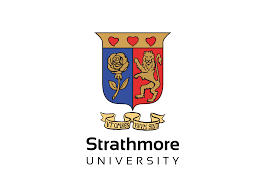

<p style="text-align: center;"><font size="5"> <font color = "blue"> Breast Cancer Detection|LogisticRegression </p>

<p style="text-align: center;"><font size="4">Samuel Irungu Kigotho</font></p>
<p style="text-align: center;"><font size="4">Adm No: 169124</font></p>
<p style="text-align: center;"><font size="4">Assigment: Regularization and SVM</font></p>
<p style="text-align: center;"><font size="4">DSA 8401: Applied Machine Learning</font></p>
<p style="text-align: center;"><font size="4">Master in Data Science and Analytic</font></p>


## Background information 

<p style='text-align: justify;'> This week’s activity focuses on studying the importance of regularization methods and practising with a new way of modelling data: Support Vectors Machines (SVM). <br>
The specific goals are: <br>
    • Practice the preprocessing of the data to get a suitable dataset. <br>
    • Study the generalization of the model when we use regularization techniques.<br>
    • Use and analyse SVM <p>  

In [7]:
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [13]:
df=pd.read_csv("https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data.csv")
df.head(10)

HTTPError: HTTP Error 404: Not Found

## Research Problem

<p style='text-align: justify;'> Diabetes mellitus refers to a collection of metabolic disorders characterized by elevated blood sugar levels 
(hyperglycemia) resulting from deficiencies in insulin action, insulin secretion, or both (American Diabetes 
Association, 2009, 1-8). According to the International Diabetes Federation (IDF, 2021), one in every ten adults, or 537 million people between the ages of 20 and 79, has diabetes. <br>
Diabetes diagnosis is critical for active care in persons who are newly diagnosed and have not 
yet acquired complications. Such people did not have the chance in advance to be aware of the early diabetes 
symptoms. It is unrealistic to expect everyone to be aware of the early symptoms. Therefore, this research focuses 
on a potential system that can assist a healthcare practitioner to early detect of diabetes using one of the frequently 
utilized classification algorithms <p>

## Research Objectives

**The objective of this Work is:**
<p style='text-align: justify;'>
To address the classification of Type 2 Diabetes using a logistic regression classifier, our goal is to apply and facilitate the implementation of the logistic regression classification technique. This approach will help standardize the diagnosis of Diabetes Mellitus within the patient dataset.<p>

## Summary of the dataset

<p style='text-align: justify;'>
The data used for this analysis was collected and provided by the "National Institute of Diabetes and Digestive and Kidney Diseases" as part of the Pima Indians Diabetes Database. The dataset comprises instances from a larger database, with specific constraints. All patients included in the dataset belong to the Pima Indian heritage, which is a subgroup of Native Americans. <p>

## Data Description 

<p style='text-align: justify;'>
First the data is publicly accessible on the Kaggle website (https://www.kaggle.com/uciml/pima-indians-diabetes-database) and 
serves as an open-source dataset comprising records of female patients. The dataset encompasses a total of 768 
cases, with each case representing a female participant from the Pima Indigenous community. Within each 
case, there is a binary indicator, indicating whether the individual is non-diabetic (0) or diabetic (1). Other features included in the data are as shown in the table below.<p>

|Attribute | Description |
|:----------|------------:|
|Pregnancies:|Number of times a Pima Indigenous female got pregnant |
|Glucose:|In an oral glucose tolerance test, plasma glucose concentration measured over 2 hours.|
|Blood Pressure:|Diastolic blood pressure (mm Hg)|
|Skin Thickness:|Thickness of Triceps skin fold (mm)|
|Insulin:|2-Hour serum insulin (mu U/ml)|
|BMI:|Body Mass Index (weight in kg/(height in m)²)|
|Diabetes Pedigree Function:|Diabetes pedigree function| 
|Age:|Age in years |
|Outcome:|0 means that a female does not have Type II diabetes, and a 1 indicates the participant has Type II diabetes|



**Pregnancies:** Number of times a Pima Indigenous female got pregnant.<br>
**Glucose Level:** Plasma glucose concentration over 2 hours in an oral glucose tolerance test. <br>
**Blood pressure:** Blood pressure refers to the force exerted by the blood as it circulates through the body's 
cardiovascular system. It plays a crucial role in maintaining proper circulation. <br>
**Skin Thickness:** Triceps skinfold thickness, measured in **millimeters (mm)** within the dataset, is a metric that offers 
a reliable estimate of both obesity and body fat distribution. <br>
**Insulin:** 
In the Pima Indigenous community, the metric used to measure the level of insulin in the blood after a two-hour 
period is denoted as **"mu U/ml" (micro-units per milliliter)**. In the context of the dataset, the variable labeled 'Insulin' 
represents the two-hour serum insulin level. By analyzing an individual's insulin levels following a meal, it is 
possible to identify the presence of a metabolic disorder and determine if there is a defect in islet function, both of 
which are associated with diabetes. Insulin, a peptide hormone, is primarily produced by the beta cells of the 
pancreatic islets and serves as the body's main anabolic hormone. Its role involves regulating the metabolism of 
carbohydrates, fats, and proteins by facilitating the absorption of glucose from the bloodstream into the liver, adipose 
tissue (fat), and skeletal muscle cells.<br> 
**BMI:** Body mass index (BMI), a measure of obesity and health, is commonly used in statistical analysis. The degree 
of obesity cannot be judged directly by the absolute value of the weight, and it is naturally related to height. So, 
BMI is defined as the body mass divided by the square of the body height.<br>
**Diabetes Pedigree Function:** The term used for this variable is DBF, which indicates the probability of developing 
diabetes depending on one's familial background (Joshi & Dhakal, 2021, 1-7). <br>
**Age:** Age (years) the range in the dataset is from 21 to 81. <br>
**Outcome:** Classification variable where 0 means that a female does not have Type II diabetes, and a 1 indicates the 
participant has Type II diabetes. <p>

## Logistic Regression 

The logistic regression equation is given by:

 $$ \hat{y} = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n)}} \ $$ 

<div style="border:1px solid black; padding: 10px;">  <br>
    where: <br>
    \(\hat{y}\) is the predicted probability of the outcome <br>
    \(\beta_0\) is the intercept,<br>
    \(\beta_1, \beta_2, \ldots, \beta_n\) are the coefficients of the model,<br>
    \(x_1,x_2, \ldots, x_n \) are the input features.<br>
</div>

## Import Libraries 

In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load sci-kit learn functions for constructing logistic regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import PredefinedSplit
from xgboost import XGBClassifier

## Data Importation 

In [4]:
# Read data
data = pd.read_csv("diabetes.csv")

## Data Exploration and Visualization

In [5]:
data.head(),

(   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 0            6      148             72             35        0  33.6   
 1            1       85             66             29        0  26.6   
 2            8      183             64              0        0  23.3   
 3            1       89             66             23       94  28.1   
 4            0      137             40             35      168  43.1   
 
    DiabetesPedigreeFunction  Age  Outcome  
 0                     0.627   50        1  
 1                     0.351   31        0  
 2                     0.672   32        1  
 3                     0.167   21        0  
 4                     2.288   33        1  ,)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


As decribed above the data contains 768 entries with 9 columns as shown above.

First of all, we are going to check the summary statistics for the numeric variables in the dataset. This involves performing univariate exploratory data analysis (EDA) for the feature variables.

In [7]:
data.describe(),

(       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
 count   768.000000  768.000000     768.000000     768.000000  768.000000   
 mean      3.845052  120.894531      69.105469      20.536458   79.799479   
 std       3.369578   31.972618      19.355807      15.952218  115.244002   
 min       0.000000    0.000000       0.000000       0.000000    0.000000   
 25%       1.000000   99.000000      62.000000       0.000000    0.000000   
 50%       3.000000  117.000000      72.000000      23.000000   30.500000   
 75%       6.000000  140.250000      80.000000      32.000000  127.250000   
 max      17.000000  199.000000     122.000000      99.000000  846.000000   
 
               BMI  DiabetesPedigreeFunction         Age     Outcome  
 count  768.000000                768.000000  768.000000  768.000000  
 mean    31.992578                  0.471876   33.240885    0.348958  
 std      7.884160                  0.331329   11.760232    0.476951  
 min      0.000000   

The dataset shows a broad range of values across various health indicators. <br>
The average number of pregnancies is 3.85, with glucose levels averaging around 120.89 mg/dL. <br> 
Blood pressure and BMI have means of 69.11 mm Hg and 31.99 kg/m², respectively. <br>
Notably, some entries have zero values which can be observed by the minimum values , likely due to data entry errors or missing measurements. <br>
These anomalies can distort statistical analyses and in our case.<br> 
    To enhance the accuracy, i will be replacing zero values in, <span style="background-color: silver"> **glucose** </span>, <span style="background-color: silver"> **BMI** </span>, <span style="background-color: silver"> **blood pressure**</span>, and <span style="background-color: silver"> **skin thickness**</span> with means adjusted for age.


## Number of zeros in each Column 

In [8]:
# Check which columns that have the value zero in their rows
zeros = (data == 0).sum()
print("Number of zero values per column:")
print(zeros)

Number of zero values per column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


We calculate the means for each of the above columns i.e  <span style="background-color: silver"> **glucose** </span>, <span style="background-color: silver"> **BMI** </span>, <span style="background-color: silver"> **blood pressure**</span>, and <span style="background-color: silver"> **skin thickness**</span> in respect to each age group and replace missing values with the average of the corresponding age range group

In [10]:
# Divide the data into groups based on age range
age_groups = pd.cut(data['Age'], bins=3)  

In [11]:
# Calculate the counts in each bin
age_group_counts = age_groups.value_counts().sort_index()
age_group_counts

(20.94, 41.0]    596
(41.0, 61.0]     147
(61.0, 81.0]      25
Name: Age, dtype: int64

In [12]:
# Calculate the average of Insulin, Glucose, BMI, and Skin Thickness for each age range group
insulin_mean_by_age = data.groupby(age_groups)['Insulin'].transform('mean')
glucose_mean_by_age = data.groupby(age_groups)['Glucose'].transform('mean')
bmi_mean_by_age = data.groupby(age_groups)['BMI'].transform('mean')
skin_thickness_mean_by_age = data.groupby(age_groups)['SkinThickness'].transform('mean')
blood_pressure_mean_by_age = data.groupby(age_groups)['BloodPressure'].transform('mean')

In [13]:
# Replace missing values of Insulin, Glucose, BMI, and Skin Thickness with the average of the corresponding age range group
data['Insulin'] = data['Insulin'].mask(data['Insulin'] == 0, insulin_mean_by_age)
data['Glucose'] = data['Glucose'].mask(data['Glucose'] == 0, glucose_mean_by_age)
data['BMI'] = data['BMI'].mask(data['BMI'] == 0, bmi_mean_by_age)
data['SkinThickness'] = data['SkinThickness'].mask(data['SkinThickness'] == 0, skin_thickness_mean_by_age)
data['BloodPressure'] = data['BloodPressure'].mask(data['BloodPressure'] == 0, blood_pressure_mean_by_age)

# Verify if the values were correctly replaced
data.describe(),  

(       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
 count   768.000000  768.000000     768.000000     768.000000  768.000000   
 mean      3.845052  121.662029      72.185362      26.449627  117.784467   
 std       3.369578   30.437485      12.153626       9.828745   94.273138   
 min       0.000000   44.000000      24.000000       7.000000    9.600000   
 25%       1.000000   99.750000      64.000000      20.000000   80.625839   
 50%       3.000000  117.000000      72.000000      23.000000   80.625839   
 75%       6.000000  140.250000      80.000000      32.000000  127.250000   
 max      17.000000  199.000000     122.000000      99.000000  846.000000   
 
               BMI  DiabetesPedigreeFunction         Age     Outcome  
 count  768.000000                768.000000  768.000000  768.000000  
 mean    32.446061                  0.471876   33.240885    0.348958  
 std      6.877122                  0.331329   11.760232    0.476951  
 min     18.200000   

In [14]:
# Check if the columns have any zero values in their rows
zeros = (data == 0).sum()
print("Number of zero values per column:")
print(zeros)

Number of zero values per column:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


We see that there are no zeros in the columns except the Outcome and the pregnancies which is expected give that there can be zero pregnancies.

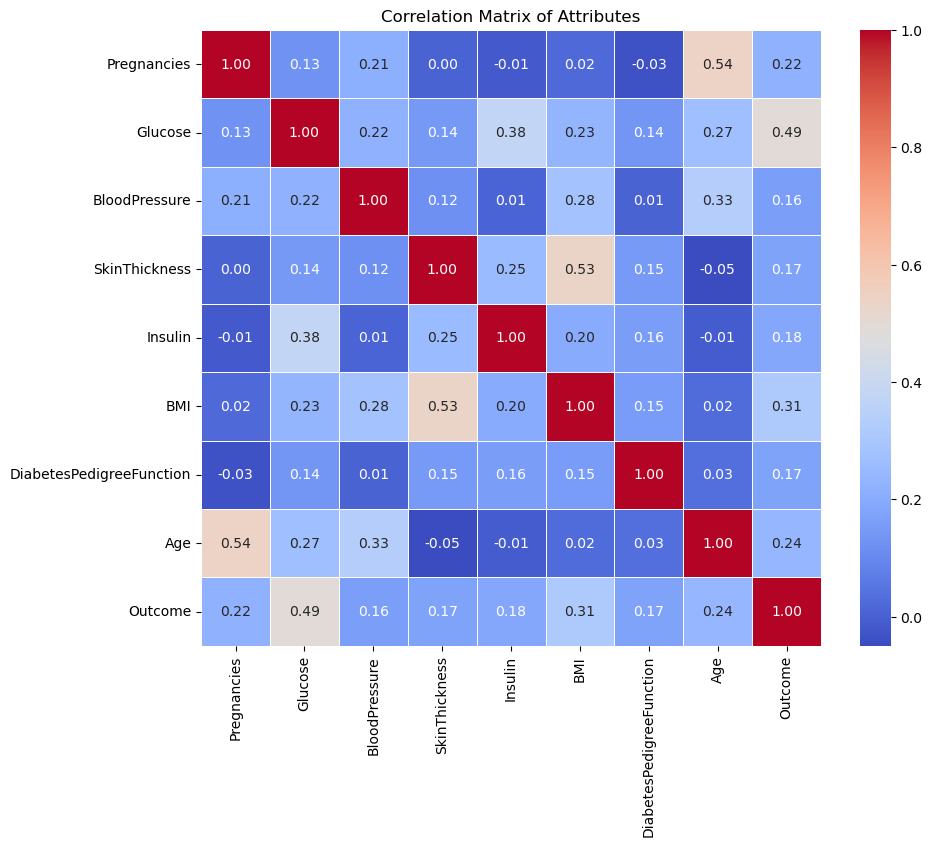

In [15]:
#Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Attributes')
plt.show()

There is a correlation between BMI & Skinthikness <br>
The Outcome is correlated with Glucose & BMI <br>
There is no reverse correlation between outcome and other independent variables <br>
We can observe some correlation between age & bloodpressure and insulin & glucose but not that evident <br>

Text(0.5, 1.0, 'BMI Vs Skinthickness')

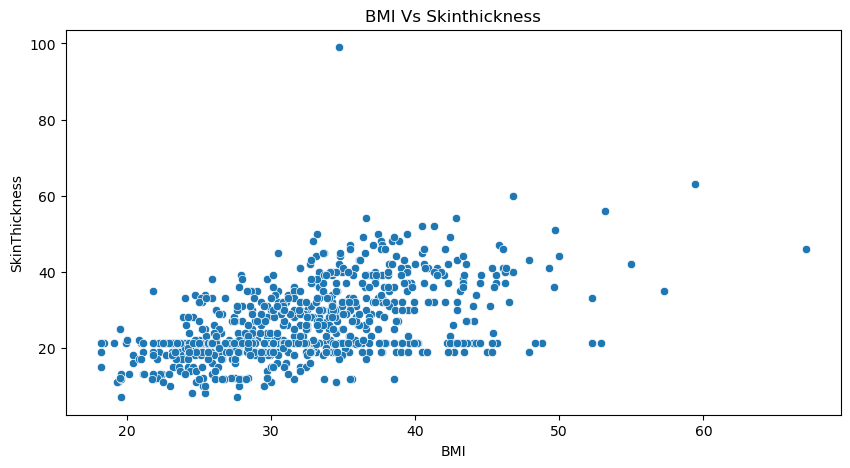

In [16]:
# Lets evaluate some more insights the data relationships
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data,x="BMI",y="SkinThickness")
plt.title('BMI Vs Skinthickness')

# Feature Selection 

 - We found a strong relationship between between two independent variable 'BMI' & 'Skinthickness'. <br>
 - But compare to Skinthickness, BMI has strong relationship with y variable 'outcome'. <br>
 - Hence to follow 'No Multicollinearity' assumption, we can drop 'Skinthickness'. <br>

# Data Modelling and evaluation

## Logistic Regression

In [17]:
# Save x & y variables
y = data['Outcome']
x = data.drop(['Outcome', 'SkinThickness'], axis=1)

In [18]:
# splitting dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y,random_state=101)

**Check that the input data, trainData and testData, are normalized, indicating the
Python code used for this. Why shouldn’t we normalize the trainLabel and testLabel sets?**

In [28]:
# Check the mean and standard deviation of trainData
print("Train Data Mean:", np.mean(x_train, axis=0))
print("Train Data Std Dev:", np.std(x_train, axis=0))

# Check the mean and standard deviation of testData
print("Test Data Mean:", np.mean(x_test, axis=0))
print("Test Data Std Dev:", np.std(x_test, axis=0))

Train Data Mean: Pregnancies                   3.789572
Glucose                     121.580168
BloodPressure                72.249293
Insulin                     119.728250
BMI                          32.576680
DiabetesPedigreeFunction      0.472095
Age                          33.487896
dtype: float64
Train Data Std Dev: Pregnancies                  3.400959
Glucose                     31.285970
BloodPressure               12.268542
Insulin                     97.493748
BMI                          6.884788
DiabetesPedigreeFunction     0.331875
Age                         11.764778
dtype: float64
Test Data Mean: Pregnancies                   3.974026
Glucose                     121.852327
BloodPressure                72.036742
Insulin                     113.265803
BMI                          32.142414
DiabetesPedigreeFunction      0.471368
Age                          32.666667
dtype: float64
Test Data Std Dev: Pregnancies                  3.284388
Glucose                     28.29

trainLabel and testLabel should not be normalized because they represent categorical outcomes, while normalization is intended for continuous numerical features (like those in trainData and testData).

In [19]:
# Build regression model
model=LogisticRegression(max_iter=200)
model.fit(x_train,y_train)
# Save the prediction
y_pred=model.predict(x_test)

In [23]:
log_reg = LogisticRegression()  # Create the model
log_reg.fit(x_train, y_train)   # Train the model using training data

C:\Users\SAM-PC\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

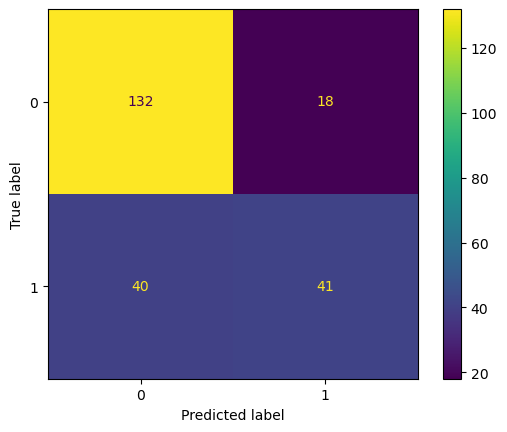

In [24]:
cm=confusion_matrix(y_test,y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

**True Negatives (TN):** The count of observations that a classifier correctly predicted as False 132 <br>
**True Positives (TP):** The count of observations that a classifier correctly predicted as True 41 <br>
**False Positives (FP):** The count of observations that a classifier incorrectly predicted as True 18 <br>
**False Negatives (FN):** The count of observations that a classifier incorrectly predicted as False 40 <br>

In [25]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.88      0.82       150
           1       0.69      0.51      0.59        81

    accuracy                           0.75       231
   macro avg       0.73      0.69      0.70       231
weighted avg       0.74      0.75      0.74       231



**Precision:** <br>
Precision measures the proportion of true positive predictions among all positive predictions made by the model. Here the precision for the "diabetic" class is 0.69, which means that 69% of the predicted as diabetic by the model were actually diabetic.<br>

**Recall:** <br> 
Recall measures the proportion of true positive predictions among all actual positive instances in the dataset. Here the recall for the "diabetic" class is 0.51, indicating that the model correctly identified 51% of all diabetics.<br>

**F1-score:** <br>
The F1-score is the harmonic mean of precision and recall. It provides a single score that balances both precision and recall. Here the F1-score for the "diabetic" class is 0.59, which indicates a balance between precision and recall. <br>

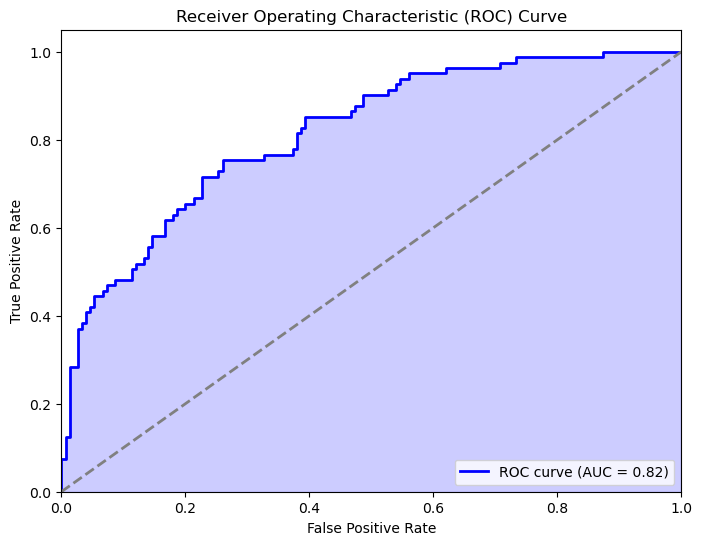

In [26]:
# ROC curve & AUC
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba = log_reg.predict_proba(x_test)[:, 1]  # Probability estimates for the positive class

# Compute ROC Curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Compute AUC
auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC Curve with shaded area
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue')              # Shade the area under the curve
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


- The more that the **Receiver Operating Characteristic (ROC) curve** hugs the top left corner of the plot, the better the model does at classifying the data.
- **AUC (Area Under the Curve)** is 0.69, that means 69% of the classifier’s predictions are correct across all classification thresholds.

## Naive Bayes (GaussianNB)

Gaussian Naive Bayes (GaussianNB) is a classification algorithm based on Bayes' theorem. 
It assumes that the features follow a normal (Gaussian) distribution and that they are independent given the class.

In [61]:
gnb=GaussianNB()
gnb.fit(x_train,y_train)
y_pred1=gnb.predict(x_test)

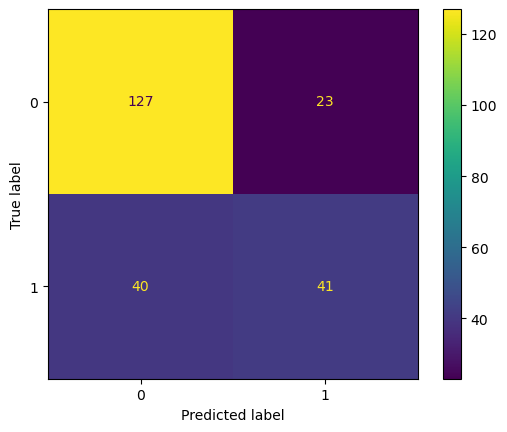

In [41]:
cm1=confusion_matrix(y_test,y_pred1)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm1)
disp.plot()

**True Negatives (TN):** The count of observations that a classifier correctly predicted as False 127 <br>
**True Positives (TP):** The count of observations that a classifier correctly predicted as True 41 <br>
**False Positives (FP):** The count of observations that a classifier incorrectly predicted as True 23 <br>
**False Negatives (FN):** The count of observations that a classifier incorrectly predicted as False 40 <br>

In [62]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.77      0.84      0.80       150
           1       0.64      0.53      0.58        81

    accuracy                           0.73       231
   macro avg       0.71      0.69      0.69       231
weighted avg       0.72      0.73      0.72       231



**Precision:** <br>
Here the precision for the "diabetic" class is 0.64, which means that 64% of the predicted as diabetic by the model were actually diabetic.<br>

**Recall:** <br> 
Here the recall for the "diabetic" class is 0.51, indicating that the model correctly identified 51% of all diabetics.<br>

**F1-score:** <br>
Here the F1-score for the "diabetic" class is 0.57.

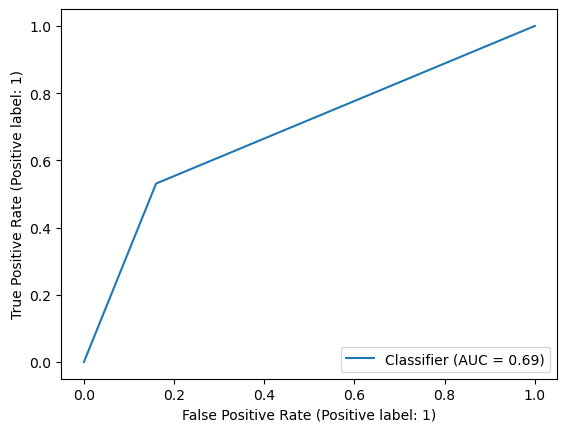

In [67]:
# ROC curve & AUC
RocCurveDisplay.from_predictions(y_test, y_pred1)
plt.show()

- **AUC (Area Under the Curve)** is 0.68, that means 68% of the classifier’s predictions are correct across all classification thresholds.

## Decision Tree Classifier

In [63]:
#hyperparameters
tree_para={'max_depth':[2,4,5,6,7,8,9,10],'min_samples_leaf':[2,5,10,20,30,40,50]}
#scoring
scoring={'accuracy','precision','recall','f1'}

tuned_decision_tree=DecisionTreeClassifier(random_state=101)
clf=GridSearchCV(tuned_decision_tree,tree_para,scoring=scoring,cv=5,refit="f1")
clf.fit(x_train,y_train)

# Predict the labels of the test set
y_pred2 = clf.predict(x_test)
y_pred2
clf.best_estimator_

DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=101)

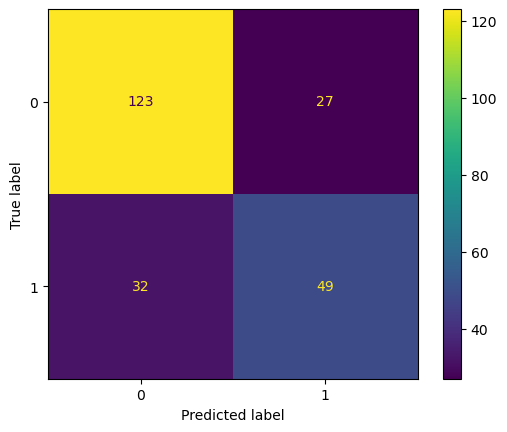

In [64]:
cm2=confusion_matrix(y_test,y_pred2)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm2)
disp.plot()

**True Negatives (TN):** The count of observations that a classifier correctly predicted as False 123 <br>
**True Positives (TP):** The count of observations that a classifier correctly predicted as True 49 <br>
**False Positives (FP):** The count of observations that a classifier incorrectly predicted as True 27 <br>
**False Negatives (FN):** The count of observations that a classifier incorrectly predicted as False 32 <br>

In [66]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.79      0.82      0.81       150
           1       0.64      0.60      0.62        81

    accuracy                           0.74       231
   macro avg       0.72      0.71      0.72       231
weighted avg       0.74      0.74      0.74       231



**Precision:** <br>
Here the precision for the "diabetic" class is 0.64, which means that 64% of the predicted as diabetic by the model were actually diabetic.<br>

**Recall:** <br> 
Here the recall for the "diabetic" class is 0.60, indicating that the model correctly identified 60% of all diabetics.<br>

**F1-score:** <br>
Here the F1-score for the "diabetic" class is 0.62.

## Random Forest

In [69]:
cv_params={'max_depth':[2,3,4,5,None],
           'min_samples_leaf':[1,2,3],
           'min_samples_split':[2,3,4],
           'max_features':[2,3,4],
           'n_estimators':[75,100,125,150]}
rf=RandomForestClassifier(random_state=0)
scoring={'accuracy','precision','recall','f1'}

In [73]:
x_tr,y_tr,x_val,y_val=train_test_split(x_train,y_train,test_size=0.2,stratify=y_train,random_state=10)
split_index=[0 if x in x_val.index else-1 for x in x_train.index]

custom_split=PredefinedSplit(split_index)

In [78]:
rf_val=GridSearchCV(rf,cv_params,scoring=scoring,cv=custom_split,refit='f1')

In [79]:
%%time
rf_val.fit(x_train,y_train)

CPU times: total: 1min 46s
Wall time: 1min 46s


GridSearchCV(cv=PredefinedSplit(test_fold=array([0, 0, ..., 0, 0])),
             estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [2, 3, 4, 5, None],
                         'max_features': [2, 3, 4],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [75, 100, 125, 150]},
             refit='f1', scoring={'f1', 'recall', 'precision', 'accuracy'})

In [81]:
# Predict the labels of the test set
y_pred3 = rf_val.predict(x_test)
y_pred3
rf_val.best_params_

{'max_depth': 3,
 'max_features': 4,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 125}

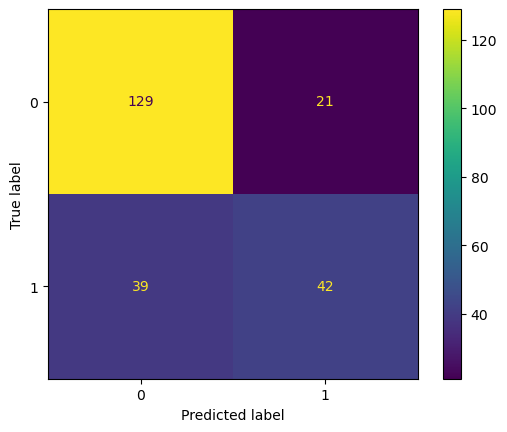

In [82]:
cm3=confusion_matrix(y_test,y_pred3)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm3)
disp.plot()

**True Negatives (TN):** The count of observations that a classifier correctly predicted as False 129 <br>
**True Positives (TP):** The count of observations that a classifier correctly predicted as True 42 <br>
**False Positives (FP):** The count of observations that a classifier incorrectly predicted as True 21 <br>
**False Negatives (FN):** The count of observations that a classifier incorrectly predicted as False 39 <br>

In [84]:
print(classification_report(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.77      0.86      0.81       150
           1       0.67      0.52      0.58        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231



**Precision:** <br>
Here the precision for the "diabetic" class is 0.67, which means that 67% of the predicted as diabetic by the model were actually diabetic.<br>

**Recall:** <br> 
Here the recall for the "diabetic" class is 0.52, indicating that the model correctly identified 52% of all diabetics.<br>

**F1-score:** <br>
Here the F1-score for the "diabetic" class is 0.58.

## XGBoosting

In [89]:
cv_params={'max_depth':[4,5,6,7,8],
           'min_child_weight':[1,2,3,4,5],
           'learning_rate':[0.1,0.2,0.3],
           'n_estimators':[75,100,125,150]}
xgb=XGBClassifier(objective='binary:logistic',random_state=0)
scoring={'accuracy','precision','recall','f1'}

In [90]:
xgb_cv=GridSearchCV(xgb,cv_params,scoring=scoring,cv=5,refit='f1')

In [91]:
%%time
xgb_cv.fit(x_train,y_train)

CPU times: total: 41min 10s
Wall time: 6min 59s


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=0, ...),
             param_grid={'learning_rate': [0.1, 0.2, 0.3],
                         'max_depth': [4, 5, 6, 7, 8],
                         'min_child_weight': [1, 2, 3, 4, 5],
                         'n_estimators': [75, 100, 125, 150]},
             refit='f1', scoring={'f1', 'recall', 'precision', 'accuracy'})

In [93]:
# Predict the labels of the test set
y_pred4 = xgb_cv.predict(x_test)
y_pred4
xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 6,
 'min_child_weight': 4,
 'n_estimators': 125}

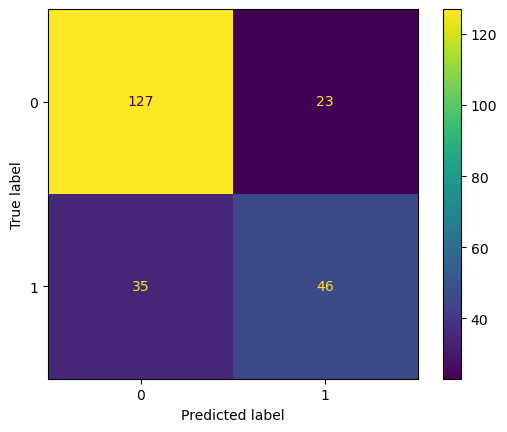

In [94]:
cm4=confusion_matrix(y_test,y_pred4)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm4)
disp.plot()

**True Negatives (TN):** The count of observations that a classifier correctly predicted as False 127 <br>
**True Positives (TP):** The count of observations that a classifier correctly predicted as True 46 <br>
**False Positives (FP):** The count of observations that a classifier incorrectly predicted as True 23 <br>
**False Negatives (FN):** The count of observations that a classifier incorrectly predicted as False 35 <br>

In [95]:
print(classification_report(y_test,y_pred4))

              precision    recall  f1-score   support

           0       0.78      0.85      0.81       150
           1       0.67      0.57      0.61        81

    accuracy                           0.75       231
   macro avg       0.73      0.71      0.71       231
weighted avg       0.74      0.75      0.74       231



**Precision:** <br>
Here the precision for the "diabetic" class is 0.67, which means that 67% of the predicted as diabetic by the model were actually diabetic.<br>

**Recall:** <br> 
Here the recall for the "diabetic" class is 0.57, indicating that the model correctly identified 57% of all diabetics.<br>

**F1-score:** <br>
Here the F1-score for the "diabetic" class is 0.61.

In [96]:
print('Linear Regression:',classification_report(y_test,y_pred))
print('Naive Bayes:',classification_report(y_test,y_pred1))
print('Decision Tree:',classification_report(y_test,y_pred2))
print('Random Forest:',classification_report(y_test,y_pred3))
print('XGBoost:',classification_report(y_test,y_pred4))

Linear Regression:               precision    recall  f1-score   support

           0       0.78      0.87      0.82       150
           1       0.69      0.53      0.60        81

    accuracy                           0.75       231
   macro avg       0.73      0.70      0.71       231
weighted avg       0.75      0.75      0.74       231

Naive Bayes:               precision    recall  f1-score   support

           0       0.77      0.84      0.80       150
           1       0.64      0.53      0.58        81

    accuracy                           0.73       231
   macro avg       0.71      0.69      0.69       231
weighted avg       0.72      0.73      0.72       231

Decision Tree:               precision    recall  f1-score   support

           0       0.79      0.82      0.81       150
           1       0.64      0.60      0.62        81

    accuracy                           0.74       231
   macro avg       0.72      0.71      0.72       231
weighted avg       0.74    

# Conclusion

<p style='text-align: justify;'>
This researchwork focused on predicting diabetes in women using the Pima Indigenous diabetes dataset specifically designed for female subjects. <br>
The dataset  included various attributes such as pregnancies, glucose levels, blood pressure, skin thickness, insulin levels, BMI, diabetes pedigree function, and age, which were utilized for the prediction process. Logistic regression algorithm and Naive Bayes (GaussianNB) 
were employed for this purpose. <br>
The outcomes revealed that Logistic Regression and XGBoosting achieved an accurate classification 
rate of 75% for the dataset the Decision Tree Classifier and Random Forest achieved an accurate classification rate of 74%,  Naive Bayes (GaussianNB) achieved an accurate classification rate of 73%. <p>

**Challenges** <br>
The dataset used in this study had a relatively small size and a limited number of 
instances. <br>
This study focused exclusively on the Pima Indigenous diabetes dataset 
for women, without incorporating additional diabetes datasets.

## References 

<p style='text-align: justify;'>
<ol>
    <li> American Diabetes Association. (2009). Diagnosis and classification of diabetes mellitus. Diabetes Care. 
33 (Suppl. 1), 62–67.</li>
    <li>Joshi, Ram & Dhakal, Chandra (2021). Predicting Type 2 Diabetes Using Logistic Regression and 
Machine Learning Approaches. International Journal of Environmental Research and Public Health. 18 
        (14), 1-17.</li>
<li> International Diabetes Federation. IDF Diabetes Atlas, 10th edn. Brussels, Belgium: 2021. Available at: https://www.diabetesatlas.org </li>


</ol>
<p>
